In [1]:
# import packages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
pd.options.display.max_rows

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import KFold, cross_val_score

In [2]:
# import the diamonds dataset
diamonds = sns.load_dataset('diamonds')
diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


# Correlation and Covariance

## Variance

Variance $\sigma^2$ as a measure of spread for continuous variables from its mean value. For the standard deviation, we just take the square root of the variance.

**Example**: Here we have a small data about monthly ice cream sales for a small ice cream vendor.

| Month   |   Amount  |
|----------|-----|
|  January | 100 |
| February | 200 |
| March    | 300 |
| April    | 500 |
| May      | 900 |

In [3]:
# values from the table in a list
amount = [100, 200, 300, 500, 900]

In [4]:
print('The amount mean:', np.mean(amount))
print('The amount variance:', np.var(amount))
print('The amount standard deviation:', np.std(amount))

The amount mean: 400.0
The amount variance: 80000.0
The amount standard deviation: 282.842712474619


## Covariance

Covariance is a measure of two joint variable variances. Suppose the greater values of one variable mainly correspond with the greater values of the other variable, and the same is for the lesser values. In that case, these variables tend to show similar behaviour. Thus, we will say that our covariance is positive.

The formula for covariance:

$$\sigma_{XY} = \dfrac{(x_1 -\mu_x)(y_1 - \mu_y) + (x_2 -\mu_x)(y_2 - \mu_y) + ... + (x_n -\mu_x)(y_n - \mu_y)}{n}$$

The x and y values in this formula are the individual data points in the dataset, while $\mu_x$ and $\mu_y$ are the means of datasets X and Y. Summing up these products across all data points gives the combined variability for all data points, and dividing by n (the number of data points) gives the average joint variability, which is the covariance.

**Example**: Suppose we have data for 3 ice-cream vendors instead of 1. We would like to see if Vendor A and Vendor Bhave similar sales across the year. We want to check the same thing for Vendor A and Vendor C, and Vendor B and Vendor C. The covariance formula requires us to have of the same number of values for each variable.

In [5]:
sales = pd.DataFrame([['January',100, 220, 900],
             ['February', 200, 400, 800],
             ['March',300, 600, 500],
             ['April', 500, 900, 1400],
             ['May',900, 1300, 2000]
             ], columns = ['month', 'vendor_a', 'vendor_b', 'vendor_c'])
sales

,month,vendor_a,vendor_b,vendor_c
0,January,100,220,900
1,February,200,400,800
2,March,300,600,500
3,April,500,900,1400
4,May,900,1300,2000


Then, we can use the `.cov()` function in numpy to calculate the covariance between vendors A, B and C, making sure to only select the numerical columns.

The parameter `ddof = 0` stands for delta degrees of freedom and calculates the covariance using the formula for the entire dataset. If you just wanted to calculate the covariance for a sample of the dataset, you would use `ddof = 1`. 

In [6]:
# calculate covariance
sales = sales[['vendor_a', 'vendor_b', 'vendor_c']]
sales.cov(ddof=0)

,vendor_a,vendor_b,vendor_c
vendor_a,80000.0,106800.0,132000.0
vendor_b,106800.0,145824.0,169520.0
vendor_c,132000.0,169520.0,277600.0


## Pearson Correlation coefficient (r)

Pearson's Correlation Coefficient, often represented as $r$, provides a measure of the strength and direction of a linear relationship between two variables. 

It ranges from -1 to 1, with -1 indicating a perfect negative linear relationship, 1 indicating a perfect positive linear relationship, and 0 suggesting no linear relationship.

At its core, covariance measures how two variables change together. However, it lacks a standardised scale, making it difficult to interpret on its own. Pearson's Correlation is essentially a normalised version of covariance. By dividing the covariance of the two variables by the product of their standard deviations, we obtain the correlation coefficient, which gives us a clearer, scaled indication of the relationship strength.

<br>
<br>

$$r = \frac{\sigma_{XY}}{\sigma_X \sigma_Y} \$$


<br>
<br>

We can compute the correlation coefficient using `.corr()` from pandas.


In [7]:
# correlation coefficient
sales.corr()

,vendor_a,vendor_b,vendor_c
vendor_a,1.000000,0.988808,0.885766
vendor_b,0.988808,1.000000,0.842552
vendor_c,0.885766,0.842552,1.000000


This looks good but a heatmap would be even better, as we will be able to see the strength of the correlations between each vendor at a glance.

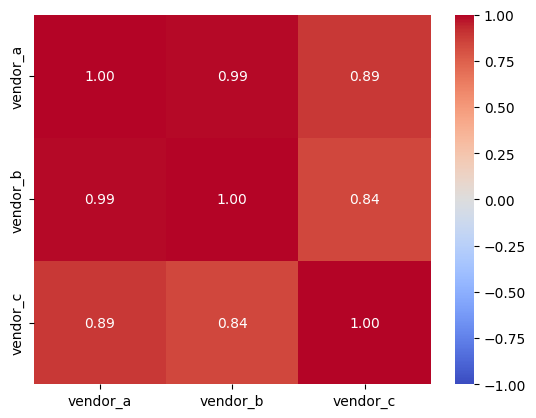

In [8]:
# create a heatmap for the correlation coefficients
sns.heatmap(sales.corr(), 
            cmap='coolwarm', 
            annot=True, 
            fmt=".2f", 
            vmin=-1, 
            vmax=1);

A summary of the parameters used:
- `cmap='coolwarm'` specifies the colour map for the heatmap. The 'coolwarm' cmap is a diverging colourmap that transitions between cool and warm colours. More colourmaps available [here](https://seaborn.pydata.org/tutorial/color_palettes.html)
- `annot=True` indicates whether or not the values should be written on each cell of the heatmap. Setting it to True will annotate the heatmap with the actual correlation values.
- `fmt=".2f"` determines the string formatting code for annotations. Here, ".2f" means that the numbers will be formatted to show two decimal places.
- `vmin=-1` sets the minimum value on the colour scale. Since Pearson's correlation coefficient ranges from -1 to 1, this ensures that -1 will be the minimum value represented in the heatmap. The same applies for `vmax=1`.


Vendor A and Vendor B have the strongest correlation at 0.99, and Vendor B and Vendor C have the weakest correlation at 0.84 (which is still very strong!).

Let's explore the diamonds dataset in the same way.

<Axes: >

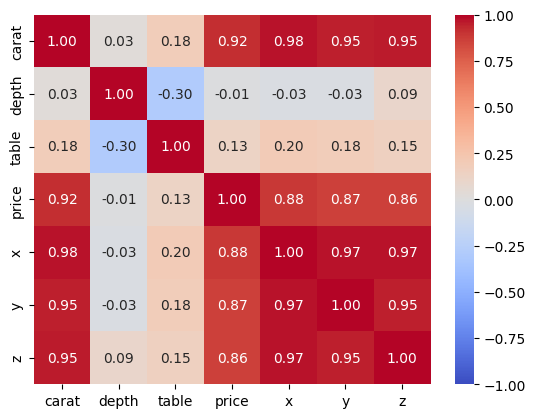

In [10]:
# select only numerical columns from diamonds
diamonds_numerical = diamonds.select_dtypes(include=['int64', 'float64'])

# heatmap for the diamonds dataset
sns.heatmap(diamonds_numerical.corr(), 
            cmap='coolwarm', 
            annot=True, 
            fmt=".2f", 
            vmin=-1, 
            vmax=1)

##### **Task 1: Identify the strongest and weakest correlations in the cars dataset**.

Notes:

<br>
<br>
<br>
<br>

# Assumptions of the linear regression model

## The problem of multicollinearity

Multicollinearity is when independent variables in the regression model are highly correlated. Due to this, the change in one variable would cause change to another, so the model results fluctuate significantly. Therefore, the model results will be unstable and vary greatly, given a slight change in the data or model.
- we cannot rely on the estimated coefficients
- the unstable nature of the model can cause over-fitting

So, when selecting the features in our model, we have to ensure that there is no multicollinearity.

Our task will be to reduce the multicollinearity, and get rid of the predictors that intersect too much with each other.
One method to do this is by checking the Pearson correlation coefficient.

### Reduce the multicolliniarity by checking the Pearson coefficient

We can create a heatmap of the diamonds dataset, to show the correlation between each variable.

In [ ]:
# creating a heatmap
plt.figure(figsize=(8, 8))  
diamonds_numerical = diamonds.select_dtypes(include=['float64', 'int64'])
sns.heatmap(diamonds_numerical.corr(), annot=True,cmap='RdYlGn',square=True)

We can also visualise this as a dataframe.

In [ ]:
corr_table = diamonds_numerical.corr()
corr_table

The first step would now be to check the strongest predictors for price. So from the dataframe, we want to select the `price` column and compare all of the correlations. You could just look at the dataframe above, but if you want to single out the price column:

In [ ]:
# add in .abs() to find the absolute values

corr_table['price'].abs().sort_values(ascending = False)

Next we want to check the correlations of the strongest predictor - from the line of code above it looks like the strongest predictor is carat. 

In [ ]:
corr_table['carat'].abs().sort_values(ascending = False)

The `x`, `y` and `z` columns have very strong positive correlations so we will exclude them from our list of features.

In [ ]:
# defining the model from the last notebook but with x, y, z missing
X = diamonds[['carat', 'depth', 'table']]
y = diamonds['price']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 2023)

model = LinearRegression()
model = model.fit(X_train, y_train)

Now let's evaluate the model. Here, we will be predicting y_test based on the values for X test. Them we can find the R squared and the errors for both the training data and the test data. The values that are commented out are what we had in our baseline model.

In [ ]:
y_predicted = model.predict(X_test)

# Train r2 = 0.8582959744536787
# Test r2 = 0.8628896236791448
# MAE = 880.7236831894986
# RMSE = 1472.1179887156522


print('Train r2 =', model.score(X_train, y_train))
print('Test r2 =', model.score(X_test, y_test))

print('MAE =', mean_absolute_error(y_test, y_predicted))
print('RMSE =', root_mean_squared_error(y_test, y_predicted))


We have a slightly smaller R squared value, but the errors are larger. What could this mean?

As a reminder: an R squared value closer to 1 indicates that a model perfectly predicts the data. Every observed value matches the model's prediction. As our R squared value is slightly higher than when using more features, this suggests the additional features (x, y, z) are providing some sort of addiitonal information that helps explain the variance in the price of the diamonds - even if the improvement is only small.

Both MAE and RMSE are measures of prediction error. MAE measures the average magnitude of the errors in a set of predictions, without considering their direction. RMSE measures the square root of the average of squared differences between prediction and actual observation. When you use more features, both MAE and RMSE decrease, indicating that the model's predictions are closer to the actual values. This is consistent with the idea that the additional features provide more information to the model, allowing it to make more accurate predictions.

A model with a higher R squared value might not always have a lower MAE or RMSE, and vice versa - the choice of which metric to prioritise depends on what you're predicting. Usually, reducing the MAE/RMSE is slightly more important than increasing the R squared value.

[The Ultimate Guide to Regression Metrics: Choose the Right One Every Time](https://medium.com/learning-data/the-ultimate-guide-to-regression-metrics-choose-the-right-one-every-time-72aada435ee7)

In [ ]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
scores
print('Mean:', scores.mean())
print('Standard deviation:', scores.std())


# from baseline model
# Mean: 0.8585572795628589
# Standard deviation: 0.003550146603760696

### Calculate the Variance Inflation Factor value

Reducing multicollinearity using the Pearson correlation is quite a manual method. We can look at a more automated method, called the Variance Inflation Factor value (VIF).

- A value of 1 indicates there is no correlation between a given explanatory variable and any other explanatory variables in the model.
- A value between 1 and 5 indicates moderate correlation between a given explanatory variable and other explanatory variables in the model, but this is often not severe enough to require attention.
- A value greater than 5 indicates potentially severe correlation between a given explanatory variable and other explanatory variables in the model. In this case, the coefficient estimates and p-values in the regression output are likely unreliable.


source: https://www.statology.org/how-to-calculate-vif-in-python/

To calculate VIF, we can import `variance_inflation_factor` and `add_constant` from the statsmodels library.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [ ]:
# The source code:

# def variance_inflation_factor(exog, exog_idx):
#     """
#     exog : ndarray, (nobs, k_vars)
#         design matrix with all explanatory variables, as for example used in
#         regression
#     exog_idx : int
#         index of the exogenous variable in the columns of exog
#     """
#     k_vars = exog.shape[1]
#     x_i = exog[:, exog_idx]
#     mask = np.arange(k_vars) != exog_idx
#     x_noti = exog[:, mask]
#     r_squared_i = OLS(x_i, x_noti).fit().rsquared
#     vif = 1. / (1. - r_squared_i)
#     return vif

Syntax : statsmodels.stats.outliers_influence.variance_inflation_factor(exog, exog_idx)

This function takes two parameters :

- exog : an array containing features/predictors on which linear regression is performed.
- exog_idx : index of the additional feature whose influence on the other features is to be measured.

First, we will drop the price, cut, color and clarity columns from the diamonds dataset as they are either categorical or the target variable.

In [ ]:
features = diamonds.drop(columns = ['price', 'cut', 'color', 'clarity'])
features

Then, we need to create a variable which is a constant and will be based on the predictors.

In [ ]:
X = add_constant(features)

Then, we will create a series based on this function, using `variance_inflation_factor`.

The function explained:

`X.values`: the values of our predictors, which we defined in the cell above.

`i`: this is each of the columns - it will be the target.

the for loop: it will iterate over all of the columns/features in X, and for each feature, it will calculate the VIF and create a list of these VIF values.

It is then sorted in descending order, so the features with the highest VIFs are at the top.

In [ ]:
pd.Series([variance_inflation_factor(X.values, i) 
               for i in range(X.shape[1])], 
              index=X.columns).sort_values(ascending = False)

The constant can be ignored, as this just represents the intercept, but what could be said about the multicollinearity in the other variables? Is there no, moderate or severe multicollinearity?

Note: If multicollinearity is extreme, there will be so much overlap that there will be no need to use both predictors as they will contain essentially the same information.

The creator of this function advised that we remove predictors 1 by 1 from the list, which will allow us to see that when remvoving one predictor, the VIF values for the remaining predictors will change.

Let's experiment with this below.

We already have removed the categorical and target variables, so we need to remove `x` from the features as well.

In [ ]:
features.drop(columns = ['x'], inplace = True)

In [ ]:
features

In [ ]:
# the same code as above
X = add_constant(features)

pd.Series([variance_inflation_factor(X.values, i) 
               for i in range(X.shape[1])], 
              index=X.columns).sort_values(ascending = False)

What do you notice about the VIF values now?

In [ ]:
features.drop(columns = ['z'], inplace = True)

In [ ]:
X = add_constant(features)

In [ ]:
pd.Series([variance_inflation_factor(X.values, i) 
               for i in range(X.shape[1])], 
              index=X.columns).sort_values(ascending = False)

In [ ]:
features.drop(columns = ['carat'], inplace = True)

In [ ]:
X = add_constant(features)

In [ ]:
pd.Series([variance_inflation_factor(X.values, i) 
               for i in range(X.shape[1])], 
              index=X.columns).sort_values(ascending = False)

Now all the values are between 1 and 5 so we can say thay we are happy with this. This means we will be using the columns `table`, `depth` and `y`. 

In [ ]:
X = features
y = diamonds['price']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.3, 
                                                    random_state = 2023
                                                   )

model2 = LinearRegression()
model2 = model2.fit(X_train, y_train)

y_predicted = model2.predict(X_test)

print('Train r2 =', model2.score(X_train, y_train))
print('Test r2 =', model2.score(X_test, y_test))

print('MAE =', mean_absolute_error(y_test, y_predicted))
print('RMSE =', root_mean_squared_error(y_test, y_predicted))

# baseline results
# Train r2 = 0.8582959744536787
# Test r2 = 0.8628896236791448
# MAE = 880.7236831894986
# RMSE = 1472.1179887156522

# pearson's results
# Train r2 = 0.85303349349134
# Test r2 = 0.8562587494939331
# MAE = 984.0692462193164
# RMSE = 1507.294684536108


We can see quite a large drop in performance here. The train R-squared is much worse than the test R-squared, and the errors have increased.

 Let's validate the model next:

In [ ]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(model2, X, y, cv=kf, scoring='r2')

print(scores)
print()
print('Mean:', scores.mean())
print()
print('Std:', scores.std())

# from the previous model (Pearsons):
# Mean: 0.8535730767800651
# Standard deviation: 0.0028481169997606774

Let's compare the mean and the standard deviation from our current model with the previous model. What can we say about it?

The one with the highest standard deviation is worse, as it shows that the model is less stable. In other words - the model's predictions are more spread out around the mean value. So, it seems like the VIF method hasn't worked very well on our data so we would stick with the Pearson method.

When you're deciding on a model, it's crucial to consider both the initial evaluation metrics (like R², MAE, RMSE) and the cross-validation results. Cross-validation provides a more comprehensive view of how your model might perform on unseen data. In this case, despite the VIF model initially appearing more promising, the cross-validation results favour the Pearson's model

### Task 2: Check for multicollinearity in the cars dataset. Select the features by using the 2 learned methods:
- by checking the Pearson coefficient. Build a model on the selected predictors
- by checking the VIF value. Compare the chosen predictors from the previous method. Build a model on the VIF predictors.

Validate the 2 models and compare their results(mean and std).

## Linearity

Another important assumption is the linearity - i.e, that the relationship between X and the mean of Y is linear. For example, we ae assuming that the price of the diamonds is linear with any of the predictors.

To check this, we can build a pairplot in seaborn. This will allow us to look at the relationships between each of the variables.

What do you notice about the relationships between the variables? Are all of the correlations linear?

In [ ]:
# create pairplot
sns.pairplot(diamonds)

### Task 3: Describe the relationships between the target and the parameters of the cars dataset.

## Mean of Residuals

Residuals are the differences between the true values and the predicted values. In an ideal world, the mean of residuals should be zero.

For more information on residuals, [this website](https://www.mas.ncl.ac.uk/ask/numeracy-maths-statistics/statistics/regression-and-correlation/residuals.html) is helpful.

In [ ]:
# create a model
X = diamonds[['carat', 'table', 'depth']]
y = diamonds['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state = 2023)

model = LinearRegression()
model = model.fit(X_train, y_train)

In [ ]:
# create a variable called estimated price 
estimated_price = model.predict(X_train)

In [ ]:
# create a table with the price and estimated price
table = pd.DataFrame(y_train)
table['estimated_price'] = estimated_price
table

In [ ]:
# create a column for errors - this will be the price minus the estimated price
table['errors'] = table['price'] - table['estimated_price']

In [ ]:
table

Note here, we don't take the absolute value of the errors, only the actual value. We want our mean of residuals to be as close to zero as possible, regardless of whether this is is the positive or negative direction. 


In [ ]:
# calculate the mean of the errors column

table['errors'].mean()
# -0.0000000000001701538898597374

The mean is very close to zero, which is good. It means our errors are balanced. (The minus sign isn't important)

#### Task 4: Find the mean of model residuals based on the cars dataset. 

## Homoscedasticity
(pronounced “homo-sked-asticity”) - means "same variance"

Homoscedasticity is an important assumption in linear regression for several reasons. It helps to ensure the validity, reliability, and interpretability of the results.

Homoscedasticity means that the residuals have equal or almost equal variance across the regression line. By plotting the error terms with estimated terms we can check that there should not be any pattern in the error terms.

In [ ]:
# code from the last notebook, where we created a table containing the errors
diamonds = sns.load_dataset('diamonds')
X = diamonds[['carat', 'table', 'depth']]
y = diamonds['price']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state = 2023)

model = LinearRegression()
model = model.fit(X_train, y_train)

estimated_price = model.predict(X_train)
# create a table with the price and estimated price
table = pd.DataFrame(y_train)
table['estimated_price'] = estimated_price
table['errors'] = table['price'] - table['estimated_price']

In [ ]:
table

We can create a graph to visualise whether the data is homoscedastic or heteroscedastic, but actually it's very difficult to tell just by looking at it. And where would we draw the line at how homoscedastic it is?

In [ ]:
# create a scatterplot to check for homoscedasticity
plt.figure(figsize = (14, 8))

plt.scatter(table['errors'], table['estimated_price'])
plt.xlabel('estimated values')
plt.ylabel('Residuals')
plt.title('Residuals vs fitted values plot for homoscedasticity check')

Instead we can use a statistical test, which will check for us whether our errors are homoscedastic or heteroscedastic. 
There are a lot of pre-built tests in the machine learning libraries we are using so we don't need to build our own, we can just use the pre-existing ones and interpret them.


Several tests exist for equal variance, with different alternative hypotheses. Let’s go with [Goldfeld Quandt](https://www.statisticshowto.com/goldfeld-quandt-test/) test as an example. 

**Null Hypothesis:** Error terms are homoscedastic. 

**Alternative Hypothesis:** Error terms are heteroscedastic.

In [ ]:
import statsmodels.stats.api as sms
from statsmodels.compat import lzip

# Conducting the Goldfeld Quandt test
name = ['F statistic', 'p-value']
test = sms.het_goldfeldquandt(table['errors'], X_train)
lzip(name, test)

To interpret these results:

The **F-statistic** is the ratio of variances to the residuals. In a homoscedastic situation (where variances are equal), we expect this ratio to be approximately 1. Our F statistic you have here, 0.9968, is very close to 1, suggesting that the variances in the two subsets of the data are quite similar.

The **p-value** tells us the probability of observing the data if the null hypothesis of the test (in this case, that the residuals are homoscedastic) is true. A high p-value suggests that there is not enough evidence to reject the null hypothesis. In our case, the p-value is 0.588.


Since the p-value is more than 0.05 in Goldfeld Quandt Test, we can't reject its null hypothesis that error terms are homoscedastic. So, we can conclude that the errors are homoscedastic.

Note: if the errors are heteroscedastic and don't have an equal variance, then this means we probably have some large outliers and this would need to be investigated and see what is wrong with the data.

#### Task 5: Check for the 'no patterns' in the model errors based on the cars dataset. Find if the error terms are homoscedastic or not.

## Normality of errors

We can also check for the normality of the errors - in a linear regression model, we would assume that the error terms follow a normal distribution. The plot below demonstrates this.

In [ ]:
sns.displot(table['errors'],kde=True)
plt.title('Normality of error')

The residual terms are pretty much normal. However, we have long tails which means we have some big outliers in the errors which might be harming the model. Let's investigate them.

In [ ]:
# viewing the errors in the table 
table['errors']

Like with homoscedasticity, we can create a plot that will show us roughly what the errors look like but we need to do a statistical test to get some proof. We will use the [Shapiro-Wilk](https://www.statskingdom.com/doc_shapiro_wilk.html) test as it is the most powerful test for the normality.

In [ ]:
from scipy.stats import shapiro

In [ ]:
stat, p_value = shapiro(table['errors'])

In [ ]:
print(f"stat = {stat}, p_value = {p_value}")

if p_value > 0.05:
    print('Probably Normal Distribution')
else:
    print('Probably not Normal Distribution')

#### Task 6: Check the normality of the model residuals based on the cars dataset.